In [1]:
from accessx.aoi import load_aoi, make_hex_grid
from accessx.graph import build_network, save_graph, load_graph
from accessx.cost import add_time_cost_constant_speed
from accessx.cost import add_slope_based_time, add_edge_cost
from accessx.isochrone import calculate_isochrones
from accessx.accessibility import count_accessible_pois, compute_nearest_poi_cost


from geopandas import read_file

## Define AOI & Create Hexagons

<Axes: >

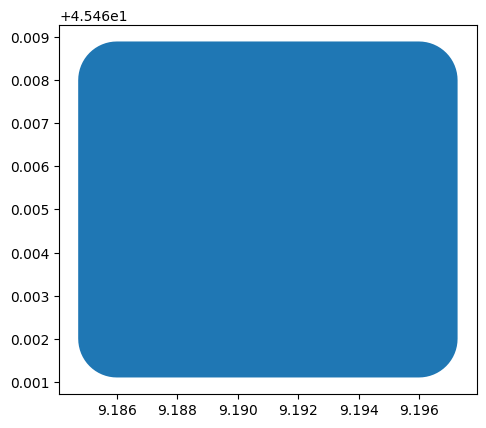

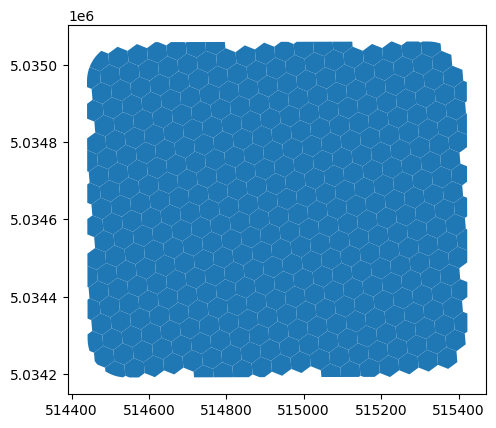

In [4]:
bbox_milano = (
    9.1860,   # minx (lon)
    45.4620,  # miny (lat)
    9.1960,   # maxx (lon)
    45.4680,  # maxy (lat)
)
city_epsg = 32632
buffer=100


aoi = load_aoi(bbox=bbox_milano, buffer_m=buffer, utm_crs=city_epsg, save_path="data/area/area_of_interest.geojson")
hexes = make_hex_grid(aoi,resolution=11, clip=True)
hexes_proj = hexes.to_crs(city_epsg)
hexes_proj.to_file('data/area/hexes.geojson', driver="GeoJSON")

aoi.plot()

hexes_proj.plot()

## Get street network

In [3]:

city_epsg = 32632
buffer=100

G_proj = build_network(
    AOI=aoi,
    city_epsg=city_epsg,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)


save_graph(
    G_proj,
    out_dir= "data/street_network/",
    base_name="original_graph",
    save_nodes=True,
    save_edges=True,
)



## Calculate cost per street segment 

### The cost can be the time to traverse a street based on a defined constant speed...

In [4]:

# time-cost based on costant speed defined by the user
G_proj = add_time_cost_constant_speed(G_proj, speed_kmh=4.5, cost_col="avg_time")


### ...or the time when using speed adjusted to the slope of the streets 
(in %, assuming slope_pct has been added to the graph)...

In [6]:
# custom cost defined by specific function that receives edge as input and returns cost
# example with function that returns time-cost based on slope-related speeds

G_proj = add_edge_cost(
    G_proj,
    cost_fn=add_slope_based_time(slope_col="slope_pct"),
    cost_col="slope_based_time",
)


### ... or your own cost function..

In [7]:
def discomfort(edge):
    bad = 1.0 if edge.get("lit") == "yes" else 1.5
    return edge["length"] * bad

G_proj = add_edge_cost(G_proj, cost_fn=discomfort, cost_col="discomfort")

### Save and load graph

In [8]:
# save_graph(
#     G_proj,
#     out_dir= "data/street_network/",
#     base_name="graph_with_cost",
#     save_nodes=False,
#     save_edges=True,
# )

city_epsg = 32632

G_proj = load_graph(out_dir="data/street_network/", base_name="graph_with_cost", crs=city_epsg)

# G_proj = load_graph(
#     nodes_path="data/street_network/graph_with_cost_nodes_OSM.geojson",
#     edges_path="data/street_network/graph_with_cost_edges_OSM.geojson",
#     crs=3044
# )

save_graph(
    G_proj,
    out_dir= "data/street_network/",
    base_name="loaded_saved_graph",
    save_nodes=False,
    save_edges=True,
)

## Calculate isochrones

In [2]:
# read street network
G_proj = load_graph(
    nodes_path="data/street_network/graph_with_cost_nodes_OSM.geojson",
    edges_path="data/street_network/graph_with_cost_edges_OSM.geojson",
    crs=32632
)

# read hex-grid
hexes_proj = read_file('data/area/hexes.geojson')


In [ ]:
import os

# Using Convex Hull
gdf_hex = calculate_isochrones(
    G_proj,
    hexes_proj,
    max_cost=15,
    interval_size=1,
    cost_attr="time_min",
    city_epsg=32632,
    max_distance=200,
    method="hull",
    n_jobs = os.cpu_count() - 1,
    edge_buff=25,
    infill=True,
    save_dir='data/walksheds/',
)

<Axes: >

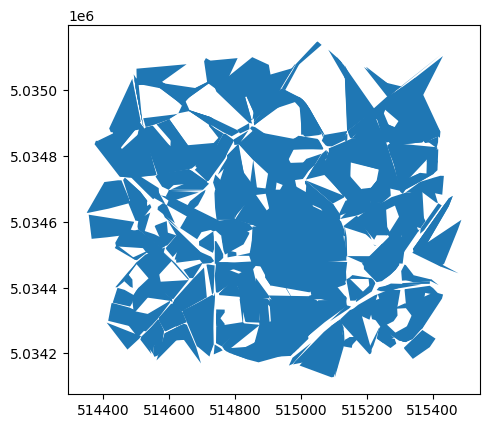

In [10]:
gdf_hex.head(3)
gdf_4 = gdf_hex.set_geometry('geom_time_min_4')
gdf_4.plot()

In [13]:
# Using Edges 

gdf_hex = calculate_isochrones(
    G_proj,
    hexes_proj,
    max_cost=15,
    interval_size=1,
    cost_attr="time_min",
    city_epsg=32632,
    max_distance=200,
    method="edges",
    n_jobs = os.cpu_count() - 1,
    edge_buff=25,
    infill=True,
    save_dir='data/walksheds/',
)

/Users/vmlias/repos/accessX/src/accessx/isochrone.py:261: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:261: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:261: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:261: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:261: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lamb

In [32]:
gdf_hex

NameError: name 'gdf_hex' is not defined

<Axes: >

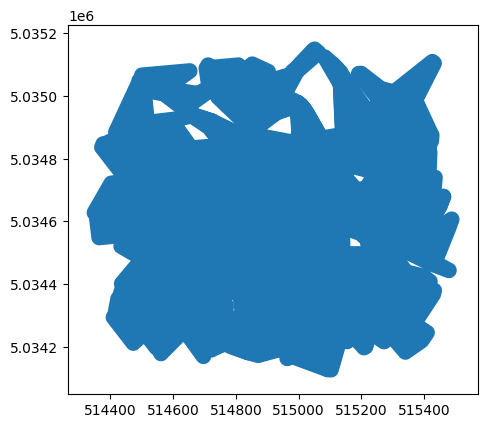

In [14]:
gdf_hex.head(3)
gdf_4 = gdf_hex.set_geometry('geom_time_min_4')
gdf_4.plot()

### Collect POIs

### Tags Library as an example of how existing categories are groupped and supported. 
Users can define their own according to OpenStreetMap Wiki https://wiki.openstreetmap.org/wiki/Map_features 

In [2]:
from accessx.poi import get_pois_osm

# example
tags_library = {
    "greenspace": {
        "leisure": ["park", "nature_reserve"],
        "landuse": ["recreation_ground", "grass", "forest"],
        "natural": ["wood", "grassland", "scrub", "heath", "hill"],
    },
    "playground": {"leisure": ["playground"]},
    "supermarket": {"shop": ["supermarket"]},
    "bakery": {"shop": ["bakery"]},
    "butcher": {"shop": ["butcher"]},
    "greengrocer": {"shop": ["greengrocer"]},
    "seafood": {"shop": ["seafood"]},
    "school": {"amenity": ["kindergarten", "school"]},
    "culture": {"tourism": ["museum", "gallery", "artwork"], "amenity": ["arts_centre"]},
    "sport": {
        "leisure": ["sports_centre", "stadium", "sports_hall", "swimming_pool", "fitness_centre",
                    "fitness_station", "pitch", "track"],
        "sport": True,
    },
    "pharmacy": {"amenity": ["pharmacy"]},
    "nightlife": {
        "amenity": ["bar", "pub", "nightclub", "music_venue", "cinema", "theatre"],
        "tourism": ["nightlife"],
    },
    "metro": {"station": ["subway"]},
    "bus_tram": {
        "highway": ["bus_stop"],
        "railway": ["tram_stop"],
        "amenity": ["bus_station"],
        "public_transport": ["stop_position"],
    },
    "public_square": {"place": ["square"], "amenity": ["marketplace", "town_square"]},
    "cafe_restaurant": {"amenity": ["cafe", "restaurant", "fast_food"]},
    "clothing_stores": {"shop": ["clothes", "boutique", "fashion_accessories", "outfitter", "tailor", "second_hand"]},
    "university": {"amenity": ["college", "university"]},
    "library": {"amenity": ["library"]},
}

### Collecting POIs

In [25]:
# clean default
pois_default = get_pois_osm(aoi, categories=["pharmacy", "school", "playground", "supermarket", "library"])

# # include a few extras
# pois_extra = get_pois_osm(aoi, categories=["pharmacy"], columns=["name", "opening_hours", "wheelchair"])

# # everything
# pois_all = get_pois_osm(aoi, categories=["pharmacy", "school"], columns="all")

In [13]:
print(list(pois_default))
print(list(pois_extra))
print(list(pois_all))
pois_default

['id', 'osmid', 'osm_type', 'category', 'geometry']
['id', 'osmid', 'osm_type', 'category', 'geometry', 'name', 'opening_hours', 'wheelchair']
['id', 'osmid', 'osm_type', 'category', 'geometry', 'addr:city', 'addr:country', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'check_date', 'dispensing', 'email', 'healthcare', 'name', 'opening_hours', 'operator', 'phone', 'ref:msal', 'ref:vatin', 'source', 'website', 'contact:phone', 'wheelchair', 'contact:website', 'contact:whatsapp', 'start_date', 'education', 'wikidata', 'wikipedia']


,id,osmid,osm_type,category,geometry
0,0,661556413,node,pharmacy,POINT (9.18827 45.46261)
1,1,715904515,node,pharmacy,POINT (9.18935 45.46486)
2,2,1038653879,node,pharmacy,POINT (9.19681 45.46287)
3,3,1529839225,node,pharmacy,POINT (9.19354 45.4625)
4,4,1678582986,node,pharmacy,POINT (9.18657 45.4627)
5,5,1678583006,node,pharmacy,POINT (9.1867 45.46378)
6,6,1821511528,node,pharmacy,POINT (9.18842 45.46415)
7,7,2066420163,node,pharmacy,POINT (9.19165 45.46131)
8,8,3336364020,node,pharmacy,POINT (9.18578 45.46766)
9,9,5350658322,node,pharmacy,POINT (9.18621 45.46589)


In [26]:
pois_default
    
pois_default.to_file('data/pois/pois_default.geojson', driver="GeoJSON")
pois_extra.to_file('data/pois/pois_extra.geojson', driver="GeoJSON")
pois_all.to_file('data/pois/pois_all.geojson', driver="GeoJSON")


NameError: name 'pois_extra' is not defined

In [2]:
# read street network
G_proj = load_graph(
    nodes_path="data/street_network/graph_with_cost_nodes_OSM.geojson",
    edges_path="data/street_network/graph_with_cost_edges_OSM.geojson",
    crs=32632
)

# read hex-grid
hexes_proj = read_file('data/area/hexes.geojson')
pois_default = read_file('data/pois/pois_default.geojson')


In [ ]:
gdf_access = count_accessible_pois(G_proj, hexes_proj, pois_default, max_cost=15, cost_attr="avg_time", max_distance_from_graph=200)

In [5]:
gdf_access_nearest = compute_nearest_poi_cost(G_proj, hexes_proj, pois_default, max_cost=15,poi_id_col='osmid', cost_attr="avg_time", max_distance_from_graph=200)

In [10]:
gdf_access_nearest = compute_nearest_poi_cost(G_proj, hexes_proj, pois_default, max_cost=15,number_of_nearest=9, poi_id_col='osmid', cost_attr="avg_time", max_distance_from_graph=200)


hex_id                                            8b1f99cd8b28fff
geometry        POLYGON ((514715.2783738004 5034206.583920497,...
nearest_pois    [(2.71780873870558, 661556413), (3.82714860611...
Name: 0, dtype: object

In [11]:
gdf_access_nearest.loc[0].nearest_pois

[(2.71780873870558, 661556413),
 (3.8271486061123707, 2066420163),
 (3.9062526358342584, 1678582986),
 (4.923935554451238, 1821511528),
 (5.174345028416524, 1678583006),
 (5.745216541471757, 1422087106),
 (6.45410809024476, 715904515),
 (6.502112060871226, 1529839225),
 (6.608456121251831, 3207374438)]